In [1]:
%pip install llama_index ftfy regex tqdm
%pip install git+https://github.com/openai/CLIP.git
%pip install torch torchvision
%pip install matplotlib scikit-image
%pip install -U qdrant_client

Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-3q_wo_sk
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-3q_wo_sk
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import requests
import re

wiki_titles = [
    "Quantum Computing",
    "The Great Wall of China",
    "Mona Lisa",
    "Black Holes",
    "The Eiffel Tower",
    "Photosynthesis",
    "The Theory of Relativity",
    "The Amazon Rainforest",
    "Ancient Egypt",
    "Artificial Intelligence"
]

data_path = Path("/mnt/disk1/sjw/data_wiki_1")

# Ensure the directory exists
data_path.mkdir(parents=True, exist_ok=True)

def sanitize_filename(title):
    # Remove characters that are invalid for filenames
    return re.sub(r'[\/:*?"<>|]', '', title)

for title in wiki_titles:
    print(f"Fetching article: {title}")
    try:
        response = requests.get(
            "https://en.wikipedia.org/w/api.php",
            params={
                "action": "query",
                "format": "json",
                "titles": title,
                "prop": "extracts",
                "explaintext": True,
            },
        )
        response.raise_for_status()  # Raise an HTTPError for bad responses
        data = response.json()
        page = next(iter(data["query"]["pages"].values()))
        wiki_text = page.get("extract", "No extract available")

        filename = sanitize_filename(title) + ".txt"
        with open(data_path / filename, "w", encoding='utf-8') as fp:
            fp.write(wiki_text)

        print(f"Saved article: {filename}")

    except requests.RequestException as e:
        print(f"Request failed for '{title}': {e}")
    except Exception as e:
        print(f"An error occurred while processing '{title}': {e}")


Fetching article: Quantum Computing
Saved article: Quantum Computing.txt
Fetching article: The Great Wall of China
Saved article: The Great Wall of China.txt
Fetching article: Mona Lisa
Saved article: Mona Lisa.txt
Fetching article: Black Holes
Saved article: Black Holes.txt
Fetching article: The Eiffel Tower
Saved article: The Eiffel Tower.txt
Fetching article: Photosynthesis
Saved article: Photosynthesis.txt
Fetching article: The Theory of Relativity
Saved article: The Theory of Relativity.txt
Fetching article: The Amazon Rainforest
Saved article: The Amazon Rainforest.txt
Fetching article: Ancient Egypt
Saved article: Ancient Egypt.txt
Fetching article: Artificial Intelligence
Saved article: Artificial Intelligence.txt


In [3]:
import wikipedia
import urllib.request

image_path = Path("/mnt/disk1/sjw/data_wiki_1")
image_uuid = 0
# image_metadata_dict stores images metadata including image uuid, filename and path
image_metadata_dict = {}
MAX_IMAGES_PER_WIKI = 30

wiki_titles = [
    "Quantum Computing",
    "The Great Wall of China",
    "Mona Lisa",
    "Black Holes",
    "The Eiffel Tower",
    "Photosynthesis",
    "The Theory of Relativity",
    "The Amazon Rainforest",
    "Ancient Egypt",
    "Artificial Intelligence"
]

# create folder for images only
if not image_path.exists():
    Path.mkdir(image_path)


# Download images for wiki pages
# Assing UUID for each image
for title in wiki_titles:
    images_per_wiki = 0
    print(title)
    try:
        page_py = wikipedia.page(title)
        list_img_urls = page_py.images
        for url in list_img_urls:
            if url.endswith(".jpg") or url.endswith(".png"):
                image_uuid += 1
                image_file_name = title + "_" + url.split("/")[-1]

                # img_path could be s3 path pointing to the raw image file in the future
                image_metadata_dict[image_uuid] = {
                    "filename": image_file_name,
                    "img_path": "./" + str(image_path / f"{image_uuid}.jpg"),
                }
                urllib.request.urlretrieve(
                    url, image_path / f"{image_uuid}.jpg"
                )
                images_per_wiki += 1
                # Limit the number of images downloaded per wiki page to 15
                if images_per_wiki > MAX_IMAGES_PER_WIKI:
                    break
    except:
        print(str(Exception("No images found for Wikipedia page: ")) + title)
        continue

Quantum Computing
The Great Wall of China
Mona Lisa
Black Holes
No images found for Wikipedia page: Black Holes
The Eiffel Tower
Photosynthesis
The Theory of Relativity
The Amazon Rainforest
Ancient Egypt
Artificial Intelligence


In [4]:
import qdrant_client
from llama_index.core import SimpleDirectoryReader
from llama_index.vector_stores.qdrant import QdrantVectorStore
from llama_index.core import VectorStoreIndex, StorageContext
from llama_index.core.indices import MultiModalVectorStoreIndex

# Create a local Qdrant vector store
client = qdrant_client.QdrantClient(path="/mnt/disk1/sjw/qdrant_db_1")

text_store = QdrantVectorStore(
    client=client, collection_name="text_collection"
)
image_store = QdrantVectorStore(
    client=client, collection_name="image_collection"
)
storage_context = StorageContext.from_defaults(
    vector_store=text_store, image_store=image_store
)

# Create the MultiModal index
documents = SimpleDirectoryReader("/mnt/disk1/sjw/data_wiki_1").load_data()
index = MultiModalVectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
)

Failed to load file /mnt/disk1/sjw/data_wiki_1/50.jpg with error: Image size (301404458 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.. Skipping...


/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/PIL/Image.py:3368: DecompressionBombWarning: Image size (100732065 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/PIL/Image.py:3368: DecompressionBombWarning: Image size (100732065 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import os


def plot_images(image_metadata_dict):
    original_images_urls = []
    images_shown = 0
    for image_id in image_metadata_dict:
        img_path = image_metadata_dict[image_id]["img_path"]
        if os.path.isfile(img_path):
            filename = image_metadata_dict[image_id]["filename"]
            image = Image.open(img_path).convert("RGB")

            plt.subplot(8, 8, len(original_images_urls) + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            original_images_urls.append(filename)
            images_shown += 1
            if images_shown >= 64:
                break

    plt.tight_layout()


plot_images(image_metadata_dict)

<Figure size 640x480 with 0 Axes>

In [6]:
def plot_images(image_paths):
    images_shown = 0
    plt.figure(figsize=(16, 9))
    for img_path in image_paths:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 9:
                break

In [7]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode

In [8]:
test_query = "Who painted the Mona Lisa?"
# generate  retrieval results
retriever = index.as_retriever(similarity_top_k=3, image_similarity_top_k=5)
retrieval_results = retriever.retrieve(test_query)

**Node ID:** 4468df83-62eb-48ea-9ea6-b541061291d8<br>**Similarity:** 0.8866344289866903<br>**Text:** == History ==


=== Creation and date ===
Of Leonardo da Vinci's works, the Mona Lisa is the only portrait whose authenticity has never been seriously questioned, and one of four works—the others b...<br>

**Node ID:** 48409ca1-23c5-4371-8c1a-e79431dbfe9b<br>**Similarity:** 0.884480328452619<br>**Text:** The Mona Lisa ( MOH-nə LEE-sə; Italian: Gioconda [dʒoˈkonda] or Monna Lisa [ˈmɔnna ˈliːza]; French: Joconde [ʒɔkɔ̃d]) is a half-length portrait painting by Italian artist Leonardo da Vinci. Conside...<br>

**Node ID:** 8f1ad28d-803a-48a8-8a70-5ddef61fa7f6<br>**Similarity:** 0.8772277850281075<br>**Text:** == Legacy ==

The Mona Lisa began influencing contemporary Florentine painting even before its completion. Raphael, who had been to Leonardo's workshop several times, promptly used elements of the ...<br>

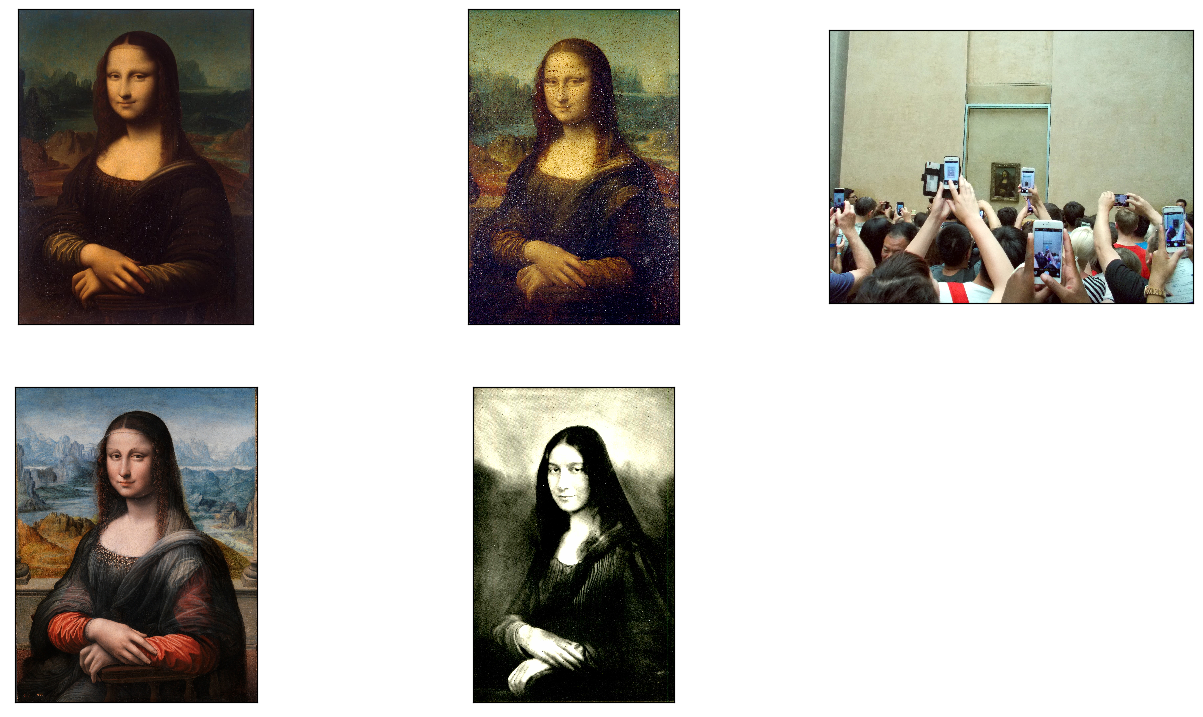

In [10]:
retrieved_image = []
for res_node in retrieval_results:
    if isinstance(res_node.node, ImageNode):
        retrieved_image.append(res_node.node.metadata["file_path"])
    else:
        display_source_node(res_node, source_length=200)

plot_images(retrieved_image)

In [15]:
retrieved_text = []

for res_node in retrieval_results:
    if not isinstance(res_node.node, ImageNode):
        retrieved_text.append(res_node.node.text)

In [12]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core import Settings

Settings.embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-small-en-v1.5"
)

In [13]:
from llama_index.core import VectorStoreIndex

vector_index = VectorStoreIndex.from_documents(documents)

In [17]:
query = f"Given the context: '{retrieved_text}'Who painted the Mona Lisa?"

index = VectorStoreIndex.from_documents(documents)
query_engine = index.as_query_engine()
response = query_engine.query(query)
print(response)

Leonardo da Vinci painted the Mona Lisa.
